# Neo4j Query Benchmark

This notebook measures the execution time of recommendation queries to analyze performance.

## 1. Setup

In [29]:
from neo4j import GraphDatabase
from dotenv import dotenv_values
import pandas as pd
import time
from functools import wraps

# Load Neo4j credentials
config = dotenv_values("Neo4j Aura Created Nov 24 2025.txt")

# Create driver connection
driver = GraphDatabase.driver(
    config["NEO4J_URI"], 
    auth=(config["NEO4J_USERNAME"], config["NEO4J_PASSWORD"])
)

def run_query(query, params=None):
    """Execute a Cypher query and return results."""
    with driver.session() as session:
        result = session.run(query, params)
        return [record.data() for record in result]

def benchmark_query(query, params=None, runs=5):
    """
    Benchmark a query by running it multiple times and measuring execution time.
    Returns: dict with min, max, avg, and results
    """
    times = []
    results = None
    
    for _ in range(runs):
        start = time.perf_counter()
        results = run_query(query, params)
        end = time.perf_counter()
        times.append((end - start) * 1000)  # Convert to milliseconds
    
    return {
        "min_ms": round(min(times), 2),
        "max_ms": round(max(times), 2),
        "avg_ms": round(sum(times) / len(times), 2),
        "runs": runs,
        "result_count": len(results) if results else 0,
        "results": results
    }

print("✅ Connected to Neo4j successfully!")

✅ Connected to Neo4j successfully!


## 2. Define All Recommendation Queries

In [30]:
# Test parameters
MOVIE_ID = 19995  # Avatar
USER_ID = 1
LIMIT = 10

# All recommendation queries from frontend.py
QUERIES = {
    "recommend_by_keyword": {
        "query": """
            MATCH (m:Movie {id: $id})-[:HAS_KEYWORD]->(k:Keyword)
            WITH m, collect(DISTINCT k) AS keywords

            MATCH (rec:Movie)-[hk:HAS_KEYWORD]->(rk:Keyword)
            WHERE rec <> m
            WITH m, rec, keywords, collect(DISTINCT rk) AS recKeywords
            WITH m, rec, size([x IN recKeywords WHERE x IN keywords]) AS commonKeywords
            WHERE commonKeywords > 0
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "recommend_by_genre": {
        "query": """
            MATCH (m:Movie {id: $id})-[hg:HAS_GENRE]->(g:Genre)
            WITH m, collect(DISTINCT g) AS genres

            MATCH (rec:Movie)-[hg:HAS_GENRE]->(rg:Genre)
            WHERE rec <> m
            WITH m, rec, genres, collect(DISTINCT rg) AS recGenres
            WITH m, rec, size([x IN recGenres WHERE x IN genres]) AS commonGeneres
            WHERE commonGeneres > 0
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "recommend_by_company": {
        "query": """
            MATCH (m:Movie {id: $id})-[:PRODUCED_BY]->(c:Company)
            WITH m, collect(DISTINCT c) AS companies

            MATCH (rec:Movie)-[:PRODUCED_BY]->(rc:Company)
            WHERE rec <> m
            WITH m, rec, companies, collect(DISTINCT rc) AS recComp
            WITH m, rec, size([x IN recComp WHERE x IN companies]) AS commonComp
            WHERE commonComp > 0
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year
            ORDER BY commonComp DESC
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "recommend_by_cast": {
        "query": """
            MATCH (m:Movie {id: $id})<-[:CASTED_IN]-(p:Person)
            WITH m, collect(DISTINCT p) AS people

            MATCH (rec:Movie)<-[:CASTED_IN]-(rp:Person)
            WHERE rec <> m
            WITH m, rec, people, collect(DISTINCT rp) AS recPerson
            WITH m, rec, size([x IN recPerson WHERE x IN people]) AS commonCast
            WHERE commonCast > 0
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year
            ORDER BY commonCast DESC
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "recommend_by_director": {
        "query": """
            MATCH (m:Movie {id: $id})
            MATCH (p:Person)-[d:WORKED_IN {job: "Director"}]->(m)
            MATCH (p)-[d2:WORKED_IN {job: "Director"}]->(rec:Movie)
            WHERE rec <> m

            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year, p.name as director
            ORDER BY rec.popularity DESC
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "recommend_by_country": {
        "query": """
            MATCH (m:Movie {id: $id})-[:PRODUCED_IN]->(pc:ProductionCountry)
            WITH m, collect(DISTINCT pc) AS countries

            MATCH (rec:Movie)-[:PRODUCED_IN]->(rpc:ProductionCountry)
            WHERE rec <> m
            WITH m, rec, countries, collect(DISTINCT rpc) AS recCountries
            WITH m, rec, size([x IN recCountries WHERE x IN countries]) AS commonCountries
            WHERE commonCountries > 0
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year
            ORDER BY commonCountries DESC, rec.popularity DESC
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "collaborative_recommendation": {
        "query": """
            MATCH (u1:User {id: $uid})
            MATCH (u1)-[:WATCHED]->(:Movie)-[:HAS_KEYWORD]->(k:Keyword)
            MATCH (u2:User)-[:WATCHED]->(:Movie)-[:HAS_KEYWORD]->(k)
            WHERE u2 <> u1
            MATCH (u2)-[:WATCHED]->(rec:Movie)
            WHERE NOT (u1)-[:WATCHED]->(rec)

            RETURN rec.id as id, rec.title as title, rec.popularity as popularity, rec.poster_url AS poster_url, 
                   rec.release_date.year AS release_year, COUNT(DISTINCT k) AS shared_kwds
            ORDER BY shared_kwds DESC, popularity DESC
            LIMIT $limit
        """,
        "params": {"uid": USER_ID, "limit": LIMIT}
    },
    "collection_recommendation": {
        "query": """
            MATCH (u:User {id: $uid})-[:WATCHED]->(watched:Movie)-[:BELONGS_TO]->(c:Collection)
            MATCH (rec:Movie)-[:BELONGS_TO]->(c)
            WHERE NOT (u)-[:WATCHED]->(rec)
            WITH rec, c, COUNT(DISTINCT watched) AS watched_from_collection
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, 
                rec.release_date.year AS release_year, c.name AS collection,
                watched_from_collection
            ORDER BY watched_from_collection DESC, rec.release_date
            LIMIT $limit
        """,
        "params": {"uid": USER_ID, "limit": LIMIT}
    },
    "language_recommendation": {
        "query": """
            MATCH (source:Movie {id: $id})-[:SPOKEN_IN]->(lang:Language)
            MATCH (recommended:Movie)-[:SPOKEN_IN]->(lang)
            WHERE recommended.id <> source.id
            RETURN DISTINCT recommended.id AS id, 
                recommended.title AS title, 
                recommended.poster_url AS poster_url,
                recommended.vote_average AS rating,
                COLLECT(DISTINCT lang.name) AS languages
            ORDER BY recommended.vote_average DESC
            LIMIT $limit
        """,
        "params": {"id": MOVIE_ID, "limit": LIMIT}
    },
    "country_recommendation": {
        "query": """
            MATCH (m:Movie {id: $uid})-[:PRODUCED_IN]->(pc:ProductionCountry)
            WITH m, collect(DISTINCT pc) AS countries

            MATCH (rec:Movie)-[:PRODUCED_IN]->(rpc:ProductionCountry)
            WHERE rec <> m
            WITH m, rec, countries, collect(DISTINCT rpc) AS recCountries
            WITH m, rec, size([x IN recCountries WHERE x IN countries]) AS commonCountries
            WHERE commonCountries > 0
            RETURN rec.id AS id, rec.title AS title, rec.poster_url AS poster_url, rec.release_date.year AS release_year
            ORDER BY commonCountries DESC, rec.popularity DESC
            LIMIT $limit
        """,
        "params": {"uid": USER_ID, "limit": LIMIT}
    }
}

print(f"Defined {len(QUERIES)} queries for benchmarking")

Defined 10 queries for benchmarking


## 3. Run Benchmark for All Queries

In [31]:
# Run benchmark for all queries
benchmark_results = []

for name, query_info in QUERIES.items():
    print(f"Benchmarking: {name}...")
    try:
        result = benchmark_query(query_info["query"], query_info["params"], runs=5)
        benchmark_results.append({
            "Query Name": name,
            "Min (ms)": result["min_ms"],
            "Max (ms)": result["max_ms"],
            "Avg (ms)": result["avg_ms"],
            "Results": result["result_count"],
            "Runs": result["runs"]
        })
        print(f"  ✅ Avg: {result['avg_ms']}ms, Results: {result['result_count']}")
    except Exception as e:
        benchmark_results.append({
            "Query Name": name,
            "Min (ms)": "ERROR",
            "Max (ms)": "ERROR",
            "Avg (ms)": "ERROR",
            "Results": 0,
            "Runs": 0
        })
        print(f"  ❌ Error: {e}")

print("\n✅ Benchmark complete!")

Benchmarking: recommend_by_keyword...
  ✅ Avg: 130.88ms, Results: 10
Benchmarking: recommend_by_genre...
  ✅ Avg: 130.88ms, Results: 10
Benchmarking: recommend_by_genre...
  ✅ Avg: 66.02ms, Results: 10
Benchmarking: recommend_by_company...
  ✅ Avg: 66.02ms, Results: 10
Benchmarking: recommend_by_company...
  ✅ Avg: 61.56ms, Results: 10
Benchmarking: recommend_by_cast...
  ✅ Avg: 61.56ms, Results: 10
Benchmarking: recommend_by_cast...
  ✅ Avg: 135.23ms, Results: 10
Benchmarking: recommend_by_director...
  ✅ Avg: 135.23ms, Results: 10
Benchmarking: recommend_by_director...
  ✅ Avg: 50.19ms, Results: 6
Benchmarking: recommend_by_country...
  ✅ Avg: 50.19ms, Results: 6
Benchmarking: recommend_by_country...
  ✅ Avg: 59.98ms, Results: 10
Benchmarking: collaborative_recommendation...
  ✅ Avg: 59.98ms, Results: 10
Benchmarking: collaborative_recommendation...
  ✅ Avg: 58.17ms, Results: 10
Benchmarking: collection_recommendation...
  ✅ Avg: 58.17ms, Results: 10
Benchmarking: collection_recommen

## 4. Results Summary

In [32]:
# Create DataFrame from benchmark results
df = pd.DataFrame(benchmark_results)
df = df.sort_values("Avg (ms)", ascending=True)
print("📊 Benchmark Results (sorted by average time):\n")
df

📊 Benchmark Results (sorted by average time):



,Query Name,Min (ms),Max (ms),Avg (ms),Results,Runs
9,country_recommendation,31.55,72.54,48.28,0,5
4,recommend_by_director,31.12,92.00,50.19,6,5
7,collection_recommendation,34.84,98.56,55.18,10,5
6,collaborative_recommendation,41.32,74.19,58.17,10,5
8,language_recommendation,48.49,81.65,59.73,10,5
5,recommend_by_country,46.46,89.31,59.98,10,5
2,recommend_by_company,44.10,111.40,61.56,10,5
1,recommend_by_genre,47.47,114.26,66.02,10,5
0,recommend_by_keyword,53.87,423.15,130.88,10,5
3,recommend_by_cast,112.43,171.96,135.23,10,5


## 5. Visualization

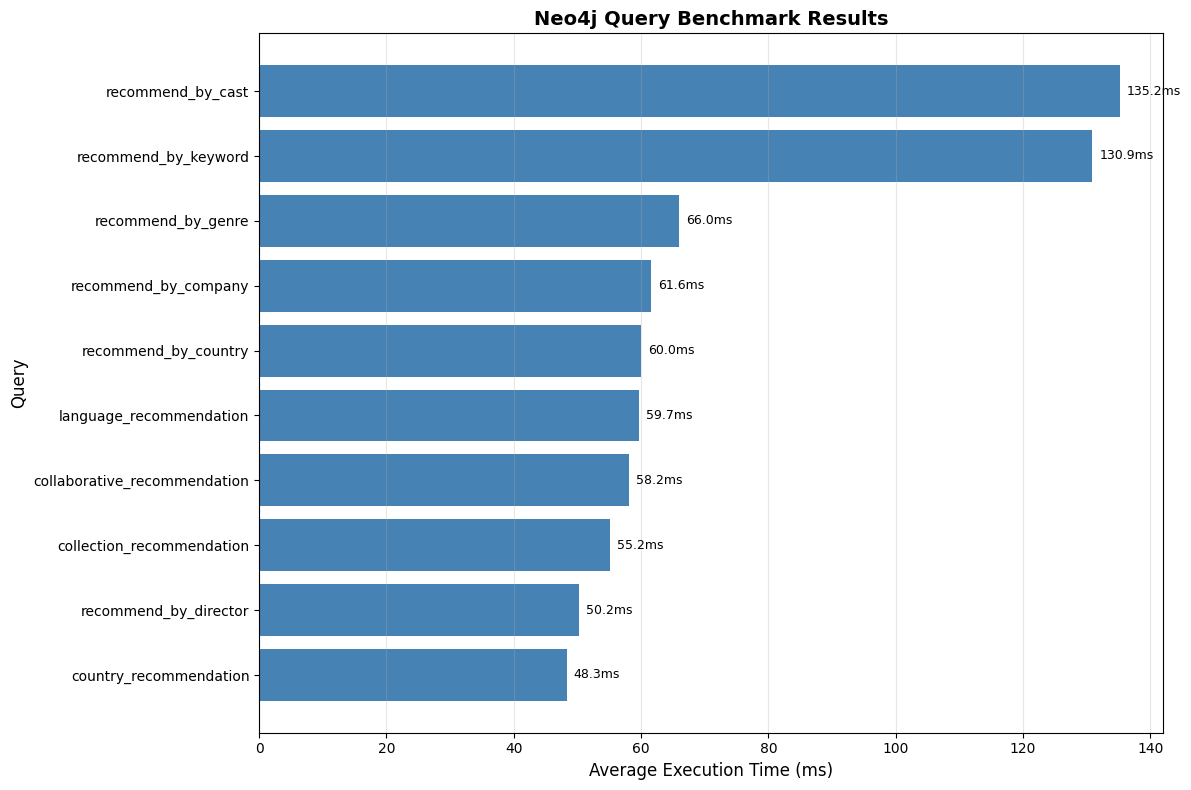

In [33]:
import matplotlib.pyplot as plt

# Filter out error rows for visualization
df_valid = df[df["Avg (ms)"] != "ERROR"].copy()
df_valid["Avg (ms)"] = pd.to_numeric(df_valid["Avg (ms)"])
df_sorted = df_valid.sort_values("Avg (ms)", ascending=True)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_sorted["Query Name"], df_sorted["Avg (ms)"], color='steelblue')

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}ms',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=9)

ax.set_xlabel('Average Execution Time (ms)', fontsize=12)
ax.set_ylabel('Query', fontsize=12)
ax.set_title('Neo4j Query Benchmark Results', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [34]:
# Summary statistics
if len(df_valid) > 0:
    fastest = df_valid.loc[df_valid["Avg (ms)"].idxmin()]
    slowest = df_valid.loc[df_valid["Avg (ms)"].idxmax()]
    
    print("=" * 60)
    print("📈 BENCHMARK SUMMARY")
    print("=" * 60)
    print(f"\n🏆 Fastest Query: {fastest['Query Name']}")
    print(f"   Average Time: {fastest['Avg (ms)']}ms")
    print(f"   Results: {fastest['Results']}")
    
    print(f"\n🐢 Slowest Query: {slowest['Query Name']}")
    print(f"   Average Time: {slowest['Avg (ms)']}ms")
    print(f"   Results: {slowest['Results']}")
    
    print(f"\n📊 Overall Statistics:")
    print(f"   Total Queries: {len(df_valid)}")
    print(f"   Average Time (all queries): {df_valid['Avg (ms)'].mean():.2f}ms")
    print(f"   Median Time: {df_valid['Avg (ms)'].median():.2f}ms")
    print(f"   Std Deviation: {df_valid['Avg (ms)'].std():.2f}ms")
    print("=" * 60)
else:
    print("❌ No valid benchmark results to summarize")

📈 BENCHMARK SUMMARY

🏆 Fastest Query: country_recommendation
   Average Time: 48.28ms
   Results: 0

🐢 Slowest Query: recommend_by_cast
   Average Time: 135.23ms
   Results: 10

📊 Overall Statistics:
   Total Queries: 10
   Average Time (all queries): 72.52ms
   Median Time: 59.85ms
   Std Deviation: 32.34ms


## 7. Close Connection

In [35]:
# Close driver connection
driver.close()
print("✅ Neo4j connection closed")

✅ Neo4j connection closed
